In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
url = "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset?select=Training"
od.download(url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: frfr
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:00<00:00, 249MB/s]


In [3]:
import os
import shutil

train_dir = "/content/brain-tumor-mri-dataset/Training"
test_dir = "/content/brain-tumor-mri-dataset/Testing"

output_dir = "/content/Data"

os.makedirs(output_dir, exist_ok=True)

for source_dir in [train_dir, test_dir]:

    for class_name in os.listdir(source_dir):

        class_path = os.path.join(source_dir, class_name)

        if not os.path.isdir(class_path):
            continue
        output_class = os.path.join(output_dir, class_name)
        os.makedirs(output_class, exist_ok=True)
        for img in os.listdir(class_path):
            src = os.path.join(class_path, img)
            new_name = f"{os.path.basename(source_dir)}_{img}"

            dst = os.path.join(output_class, new_name)

            shutil.copy2(src, dst)

print("Finished!")

Finished!


In [4]:
import pandas as pd
base_path = "/content/Data"
data = []
classes = ["glioma", "meningioma", "notumor", "pituitary"]

for cls in classes:
    folder = os.path.join(base_path, cls)

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        data.append({
            "image_path": img_path,
            "label": cls
        })

df = pd.DataFrame(data)

df.head()

,image_path,label
0,/content/Data/glioma/Training_Tr-gl_985.jpg,glioma
1,/content/Data/glioma/Training_Tr-gl_509.jpg,glioma
2,/content/Data/glioma/Training_Tr-gl_1282.jpg,glioma
3,/content/Data/glioma/Testing_Te-gl_8.jpg,glioma
4,/content/Data/glioma/Training_Tr-gl_688.jpg,glioma


In [6]:
df.shape

(7200, 2)

In [7]:
import cv2
Images = []
Labels = []
for cls in classes:
    folder_path = os.path.join(base_path, cls)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        if img is not None:
            Images.append(img)
            Labels.append(cls)

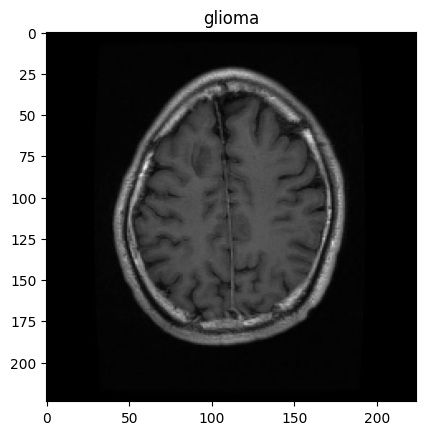

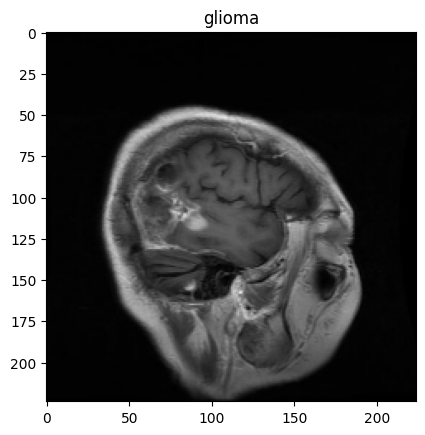

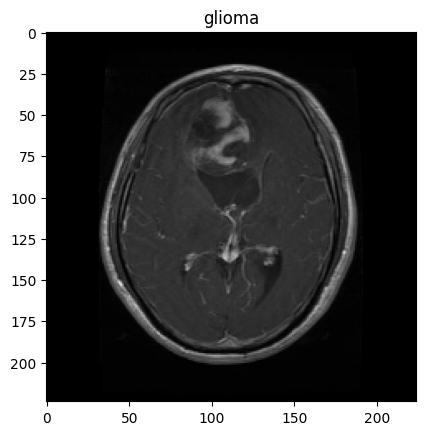

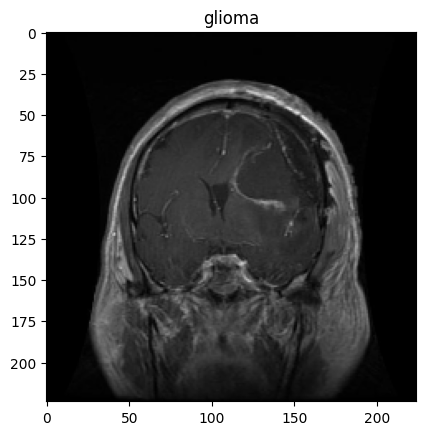

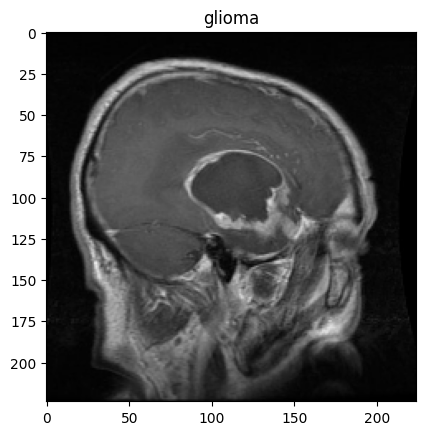

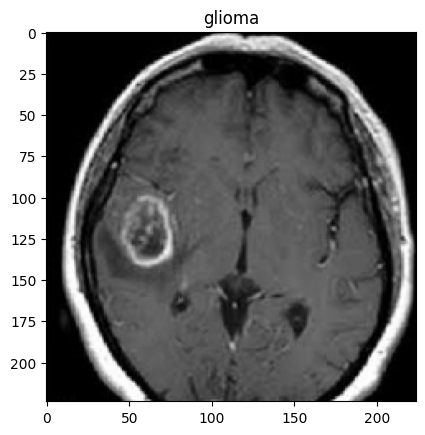

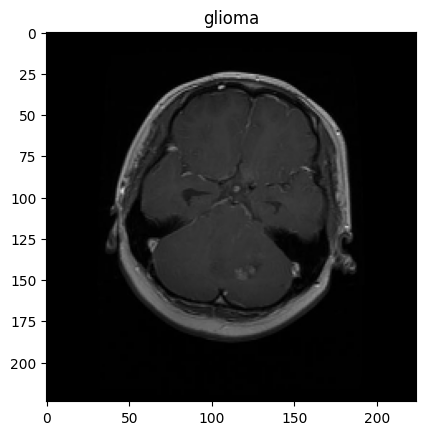

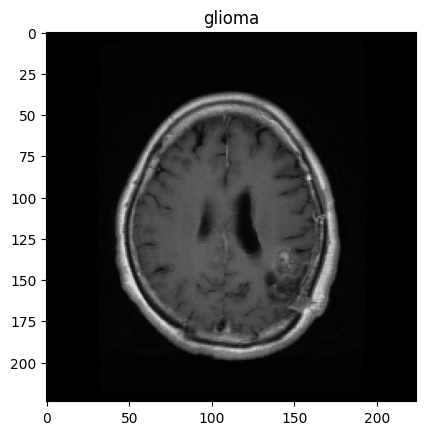

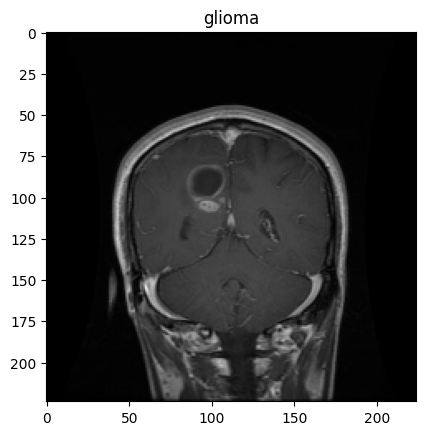

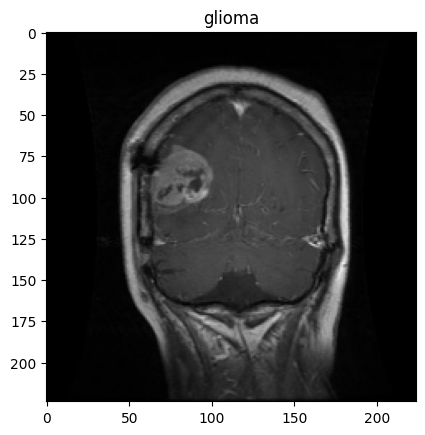

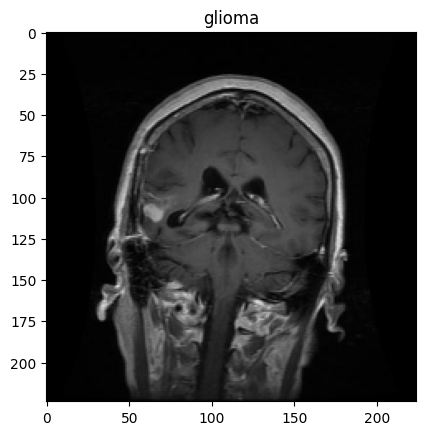

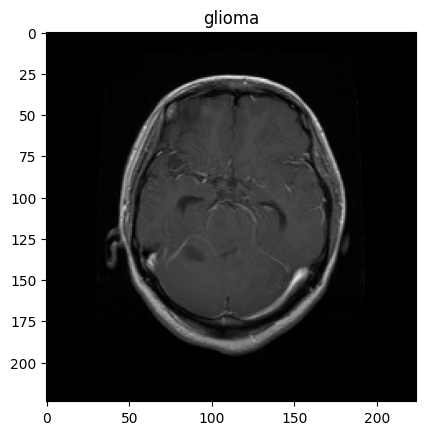

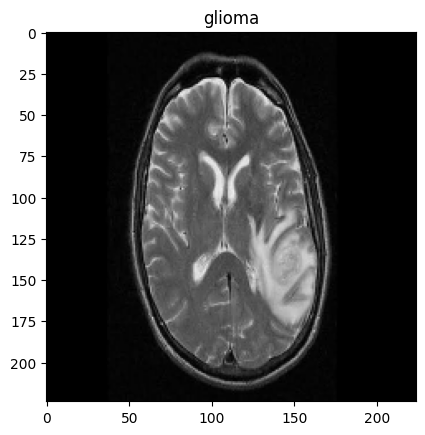

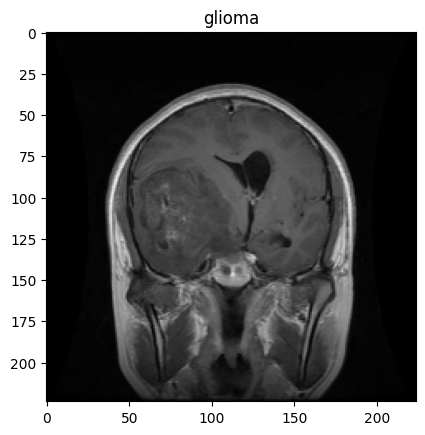

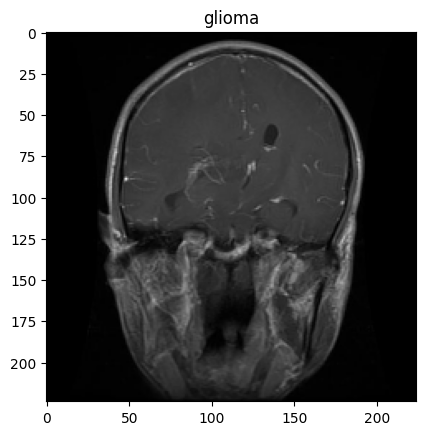

In [8]:
import matplotlib.pyplot as plt
for i, img_name in enumerate(Images[:15]):
    plt.imshow(img_name)
    plt.title(Labels[i])
    plt.show()

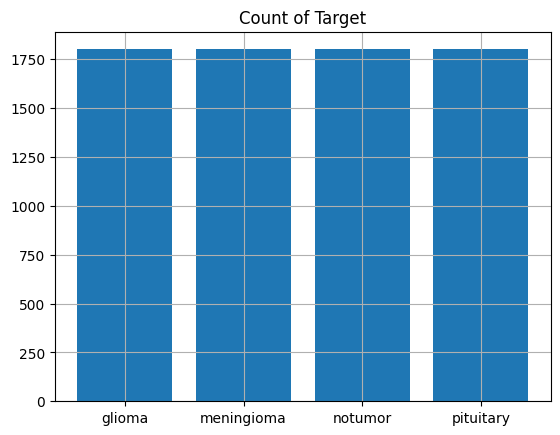

In [9]:
import matplotlib.pyplot as plt
Labels = pd.Series(Labels)
Target = Labels.value_counts()
plt.bar(Target.index, Target.values)
plt.grid(True)
plt.title("Count of Target")
plt.show()

In [10]:
Labels = Labels.map({"glioma": 0, "meningioma": 1, "notumor": 2, "pituitary": 3})

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(Images, Labels, train_size = 0.7, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size = 0.3, random_state=42)

In [12]:
import numpy as np
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

In [13]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2)
])

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

base_model = keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs, training=True)
x = keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)
model = keras.Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │     65,568 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        132 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,653,412 (90.23 MB)

 Trainable params: 65,700 (256.64 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history_ResNet50 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 34s 176ms/step - accuracy: 0.7286 - loss: 0.6967 - val_accuracy: 0.8164 - val_loss: 0.4257
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.8222 - loss: 0.4721 - val_accuracy: 0.8750 - val_loss: 0.3369
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.8474 - loss: 0.4074 - val_accuracy: 0.8673 - val_loss: 0.3463
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.8597 - loss: 0.3799 - val_accuracy: 0.8534 - val_loss: 0.3721
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.8784 - loss: 0.3499 - val_accuracy: 0.8719 - val_loss: 0.3476


In [18]:
loss, accuarcy = model.evaluate(X_test, y_test)
print(f"Test accuracy for ResNet50: {accuarcy}")
print(f"loss for ResNet50: {loss}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.8757 - loss: 0.3286
Test accuracy for ResNet50: 0.8756613731384277
loss for ResNet50: 0.3285912871360779


In [19]:
from sklearn.metrics import classification_report
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       414
           1       0.76      0.79      0.77       352
           2       0.99      0.91      0.95       372
           3       0.85      0.95      0.90       374

    accuracy                           0.88      1512
   macro avg       0.88      0.88      0.88      1512
weighted avg       0.88      0.88      0.88      1512



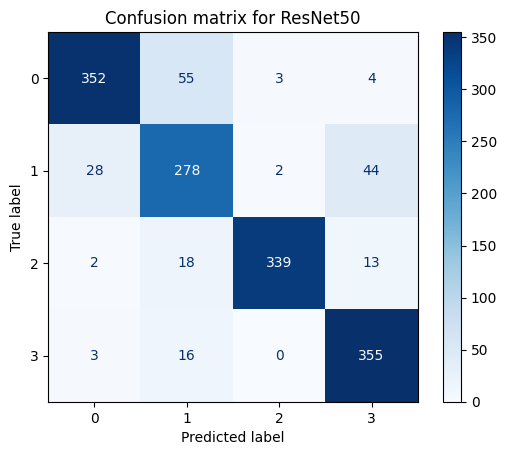

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = "Blues")
plt.title("Confusion matrix for ResNet50")
plt.show()

In [43]:
y_test = y_test.map({0: "glioma", 1: "meningioma", 2: "notumor", 3: "pituitary"})

In [39]:
y_test = y_test.map({"glioma": 0, "meningioma": 1, "notumor": 2, "pituitary": 3})

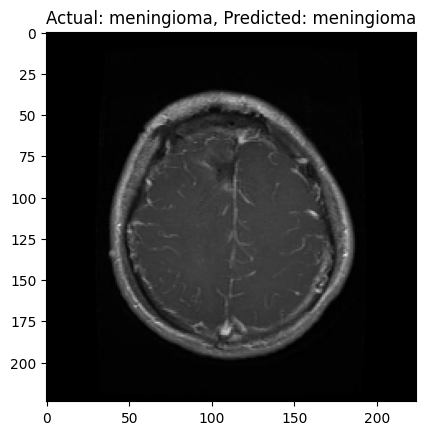

In [33]:
plt.imshow(X_test[0])
plt.title(f"Actual: {y_test.iloc[16]}, Predicted: {classes[y_pred[16]]}")
plt.show()

In [36]:
image_input_an = keras.Input(shape=(224, 224, 3))
x = data_augmentation(image_input_an, training=True)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(4, activation='softmax')(x)
model_from_scratch = keras.Model(inputs, outputs)
model_from_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_from_scratch.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │     65,568 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        132 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,653,412 (90.23 MB)

 Trainable params: 65,700 (256.64 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history_model_from_scratch = model_from_scratch.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 36s 179ms/step - accuracy: 0.8663 - loss: 0.3661 - val_accuracy: 0.8735 - val_loss: 0.3207
Epoch 2/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.8754 - loss: 0.3350 - val_accuracy: 0.8750 - val_loss: 0.3540
Epoch 3/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.8831 - loss: 0.3159 - val_accuracy: 0.8642 - val_loss: 0.3872
Epoch 4/5
158/158 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.8859 - loss: 0.3093 - val_accuracy: 0.8688 - val_loss: 0.3680


In [40]:
loss, accuarcy = model_from_scratch.evaluate(X_test, y_test)
print(f"Test accuracy for model_from_scratch: {accuarcy}")
print(f"loss for model_from_scratch: {loss}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.8763 - loss: 0.2957
Test accuracy for model_from_scratch: 0.8763227462768555
loss for model_from_scratch: 0.29570192098617554


In [41]:
from sklearn.metrics import classification_report
y_pred_prob = model_from_scratch.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       414
           1       0.86      0.65      0.74       352
           2       0.95      0.97      0.96       372
           3       0.88      0.94      0.91       374

    accuracy                           0.88      1512
   macro avg       0.88      0.87      0.87      1512
weighted avg       0.88      0.88      0.87      1512



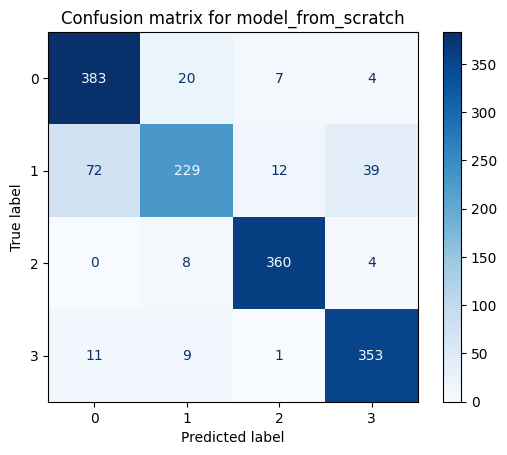

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = "Blues")
plt.title("Confusion matrix for model_from_scratch")
plt.show()

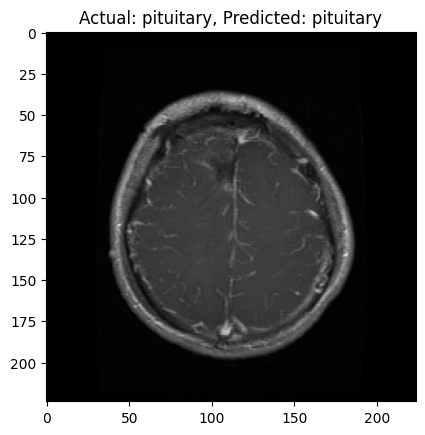

In [46]:
plt.imshow(X_test[0])
plt.title(f"Actual: {y_test.iloc[26]}, Predicted: {classes[y_pred[26]]}")
plt.show()